Load 'label' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_label.csv
Load 'tile' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_tile.csv
Loading & preparing image data...

Cropping & loading labels by 1st image:
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/images_10m/Sentinel/tiles/39UVV/2023_03_01/comp_s2_90d_b2_l2a_med.frag.0.tif
Files was loaded.
Loading from cache...
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/labels/landcover23c_v571_2023.Samara.tif
Files was loaded.
Crop labels is done.

Resizing labels by 1st image:
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/images_10m/Sentinel/tiles/39UVV/2023_03_01/comp_s2_90d_b2_l2a_med.frag.0.tif
Files was loaded.
Loading from cache...
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/pro

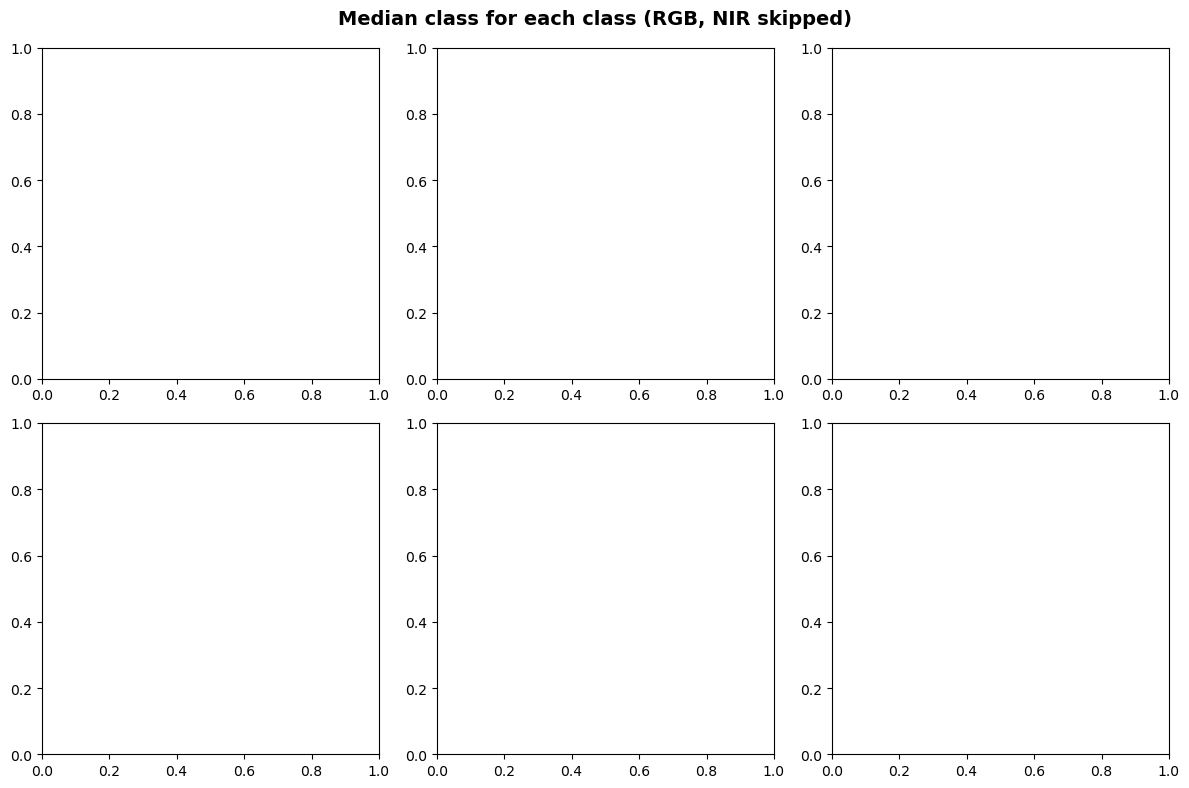

Cosine distance to median sign is calculated. Time: 1653.339s
Start stratify. Before output: [1 2 3 4 5 6] [13333602 35895936 15175667  1312076  1012090     8707]
After: mode: median & stratify True: (array([1, 2, 3, 4, 5, 6], dtype=uint8), array([4000, 4000, 4000, 4000, 4000, 4000]))
Data saved to /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/mask_median_r20_4000_stratified.tif
Mask created.

Zipping dataset by mask...
create tensor by bands
mask: (10980, 10980)
Size dataset before -> after zip by mask:
shape of signs: (24000, 15)
shape of labels: (24000,)
[1 2 3 4 5 6] [4000 4000 4000 4000 4000 4000]


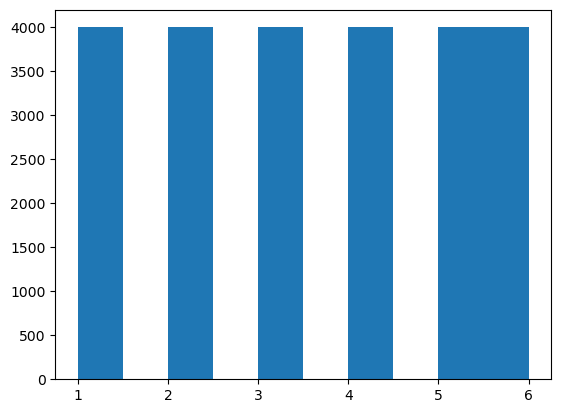

In [6]:
from utils import *
from prepare_ds import *
from train_ml import *
from create_map import *
from validation import *
from visualisation import *

force = False
downgrade_labels = force

if downgrade_labels:
    src = DEFAULT_PATH["labels"]
    out = DEFAULT_PATH["labels"] + "downgraded/"
    classes_matching = DEFAULT_PATH["labels"] + "classes_matching.csv"
    downgrade_classes(src, out, classes_matching)
    DEFAULT_PATH["labels"] = out

# you can use force=True for re-write all caches.
# signs = parse_tifs_from(DEFAULT_PATH["images"], "sign", force=force)
# signs = signs.query("type == 'sign'")

labels = parse_tifs_from(DEFAULT_PATH["labels"], "label", force=force)
labels = labels.query("type == 'label'")

year = 2023
# only_bands = ["r", "b", "g", "n", "swir1", ]
mask_mode = "median"
median_mode = "not_similar"
# layer_mode = "texture"
# layer_type = "dynamic"
stratify = True
resize = "all_signs"
r = 20
feature_percent = 0.1
count_signs = 4000

# signs_paths = (
#     signs.query(f"year == {year} and season == 'mon' and band in @only_bands")
#     .sort_values("band")
#     .sort_values("month")
# )
# label = "r36000"
label = "landcover23c"
labels_paths = labels.query(f"year == {year} and name == '{label}'")

# for 10m low RAM load
only_bands = ["r", "b", "g", "n", "swir1"]
tiles = DEFAULT_PATH["images"] + "tiles/"
tiles = parse_tifs_from(tiles, typeof="tile", force=force)
tiles = (
    tiles.query(f"year == {year} and band in @only_bands")
    .sort_values("band")
    .sort_values("month")
)
signs_paths = tiles

z_x, z_y, x, y = generate_dataset(
    signs_paths,
    labels_paths,
    count_signs,
    stratify=stratify,
    resize=resize,
    mask_mode=mask_mode,
    # layer_mode=layer_mode,
    # layer_type=layer_type,
    r=r,
    median_mode=median_mode,
    feature_percent=feature_percent,
    force=force,
    draw=True,
    verbose=True,
    save_mask=True,
)

uniq_type, uniq_count = np.unique(z_y, return_counts=True)
print(uniq_type, uniq_count)
plt.hist(z_y)
plt.show()

Split X, y -> X_train, y_train...
Start training model...
Selected model / method: RF
Model was trained. Start validate it...

Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.99      0.99       773
           2       0.98      0.98      0.98       816
           3       0.95      0.96      0.95       812
           4       1.00      1.00      1.00       819
           5       0.92      0.97      0.94       796
           6       0.93      0.88      0.91       784

    accuracy                           0.96      4800
   macro avg       0.96      0.96      0.96      4800
weighted avg       0.96      0.96      0.96      4800

Confusion Matrix:
[[769   0   0   0   0   4]
 [  0 797  19   0   0   0]
 [  0  13 779   0   0  20]
 [  0   0   0 819   0   0]
 [  0   0   0   0 769  27]
 [  6   0  22   0  64 692]]
Saving model...
Model was saved: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/tmp_weights_RF.joblib


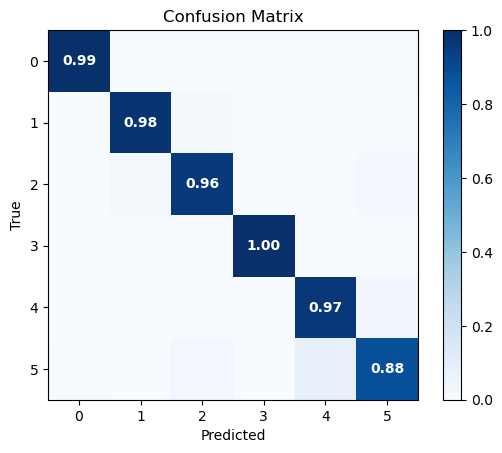

In [ ]:
m, m_rep, m_cm, f1 = train_model(z_x, z_y)
plot_confusion(m_cm)

In [ ]:
# mode 1: for usually use.
# konly_bands = ["r", "b", "g", "n", "swir1"]
# tiles = DEFAULT_PATH["images"] + "tiles/"
# tiles = parse_tifs_from(tiles, typeof="tile", force=force)
# tiles = (
#     tiles.query(f"year == {year} and band in @only_bands")
#     .sort_values("band")
#     .sort_values("month")
# )

# mode 2: for swir1/2 autoloading, because neede resise from 20 to 10m.
tiles = [sign["path"] for sign in x]

layer_mode = layer_type = None

out = f"handle_10m_{mask_mode}_stratify_{stratify}_f1_{f1:.2f}.tif"
out = DEFAULT_PATH["output"] + out
predicted = create_map(tiles, m, out, layer_mode=layer_mode, layer_type=layer_type)

Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/labels/0_comp_s2_90d_b2_l2a_med.frag.0.tif
Files was loaded.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/labels/1_comp_s2_90d_b3_l2a_med.frag.0.tif
Files was loaded.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/labels/2_comp_s2_90d_b8_l2a_med.frag.0.tif
Files was loaded.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/labels/3_comp_s2_90d_b4_l2a_med.frag.0.tif
Files was loaded.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/labels/4_comp_s2_90d_b11_l2a_med.frag.0.tif
Files was loaded.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/labels/5_comp_s2_90d_b2_l2a_med.frag.0.tif
Files was loaded.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/lab

Creating map...: 100%|██████████| 58/58 [12:12<00:00, 12.63s/it]


Map is done.
Data saved to /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_median_stratify_True_f1_0.96.tif


Load 'etalon' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_etalon.csv
Validating of:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_secure_stratify_True_f1-macro_0.63.tif
Etalons will be loaded from cache.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/etalons/r36000.2023.dw.cor.tif
Files was loaded.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_secure_stratify_True_f1-macro_0.63.tif
Files was loaded.
Etalons will be loaded from cache.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/etalons/r36000.2023.dw.cor.tif
Files was loaded.
(10980, 10980)
Data saved to /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/negative_handle_10m_secure_stratify_True_f1-macro_0.63.tif
              precision    recall  f1-score   support

           1       0.98      0.71  

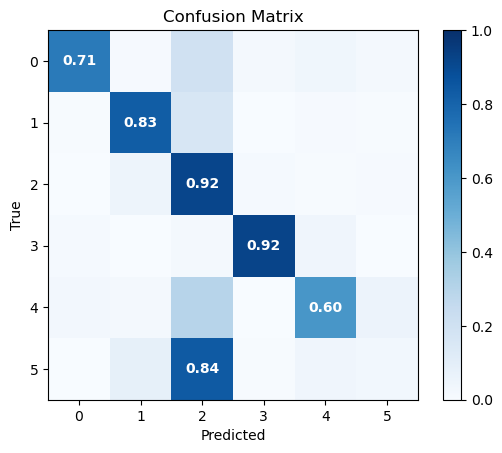

In [8]:
# Module: validation
from validation import *
from visualisation import *

year = 2023
map = "dw"
force = False

etalons = DEFAULT_PATH["etalons"]
etalons = parse_tifs_from(etalons, typeof="etalon", force=force)
etalons = etalons.query(f"year == {year} and map =='{map}'")["path"].to_list()

predicted = [
    "/Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_secure_stratify_True_f1-macro_0.63.tif",
    # "/Users/stephenhawking/Coding/ML/lokw2high_map/src/../data/output/handle_10m_texture_similar_stratify_True_f1_0.75.tif",
]

for pred in predicted:
    print("Validating of: ", pred)
    r = validate_how_tif(pred, etalons, force=force)
    # create_diff_map(predicted, etalons, "positive")
    create_diff_map(pred, etalons, "negative")

    plot_confusion(r["r36000.2023.dw.cor.tif"]["cf_matrix"])
    print(r["r36000.2023.dw.cor.tif"]["report"])

Running pipeline for params: {'mask_mode': 'texture', 'stratify': True, 'layer_mode': None, 'median_mode': 'similar', 'layer_type': 'static'}
Load 'label' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_label.csv
Load 'tile' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_tile.csv
Stage 1: generating dataset
Loading & preparing image data...

Cropping & loading labels by 1st image:
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/images_10m/Sentinel/tiles/39UVV/2023_03_01/comp_s2_90d_b2_l2a_med.frag.0.tif
Files was loaded.
Loading from cache...
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/labels/landcover23c_v571_2023.Samara.tif
Files was loaded.
Crop labels is done.

Resizing labels by 1st image:
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/images_10m/Sentinel/t

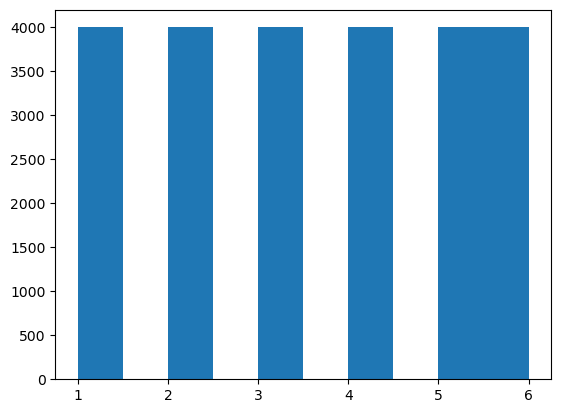

Stage 2: train model & create the map
Split X, y -> X_train, y_train...
Start training model...
Selected model / method: RF
Model was trained. Start validate it...

Classification Report:
              precision    recall  f1-score   support

           1       0.73      0.90      0.81       854
           2       0.81      0.91      0.86       813
           3       0.67      0.66      0.66       731
           4       0.76      0.59      0.67       794
           5       0.82      0.91      0.86       809
           6       0.74      0.55      0.63       799

    accuracy                           0.76      4800
   macro avg       0.75      0.75      0.75      4800
weighted avg       0.76      0.76      0.75      4800

Confusion Matrix:
[[768   9  40  20   5  12]
 [  3 742  61   0   3   4]
 [ 73 137 479  14  11  17]
 [128  11  80 470  14  91]
 [ 20   4  11   4 738  32]
 [ 56   8  49 109 134 443]]
Saving model...
Model was saved: /Users/stephenhawking/Coding/ML/low2high_map/src/../dat

Creating map...: 100%|██████████| 58/58 [1:14:41<00:00, 77.26s/it]   


Map is done.
Data saved to /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_texture_similar_stratify_True_f1_0.75.tif
Running pipeline for params: {'mask_mode': 'homogeneous', 'stratify': True, 'layer_mode': None, 'layer_type': 'static'}
Load 'label' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_label.csv
Load 'tile' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_tile.csv
Stage 1: generating dataset
Loading & preparing image data...

Cropping & loading labels by 1st image:
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/images_10m/Sentinel/tiles/39UVV/2023_03_01/comp_s2_90d_b2_l2a_med.frag.0.tif
Files was loaded.
Loading from cache...
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/labels/landcover23c_v571_2023.Samara.tif
Files was loaded.
Crop labels is done.

Resizi

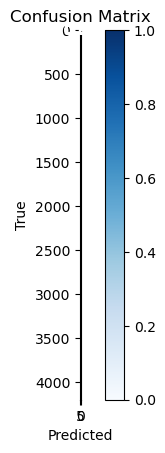

Stage 2: train model & create the map
Split X, y -> X_train, y_train...
Start training model...
Selected model / method: RF
Model was trained. Start validate it...

Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.99      0.98       807
           2       0.84      0.92      0.88       811
           3       0.83      0.77      0.80       762
           4       0.97      0.97      0.97       807
           5       0.82      0.88      0.85       795
           6       0.88      0.77      0.82       818

    accuracy                           0.88      4800
   macro avg       0.88      0.88      0.88      4800
weighted avg       0.89      0.88      0.88      4800

Confusion Matrix:
[[798   0   5   0   3   1]
 [  0 748  63   0   0   0]
 [  8 141 590   0   9  14]
 [  2   1   4 782   0  18]
 [ 10   2  27   1 699  56]
 [  5   0  20  25 138 630]]
Saving model...
Model was saved: /Users/stephenhawking/Coding/ML/low2high_map/src/../dat

Creating map...: 100%|██████████| 58/58 [43:02<00:00, 44.52s/it]   


Map is done.
Data saved to /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_homogeneous_stratify_True_f1_0.88.tif


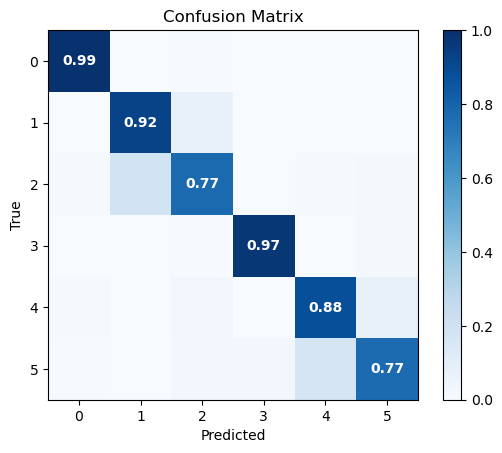

In [2]:
from utils import *
from prepare_ds import *
from train_ml import *
from create_map import *
from validation import *
from visualisation import *

force = False
downgrade_labels = force

if downgrade_labels:
    src = DEFAULT_PATH["labels"]
    out = DEFAULT_PATH["labels"] + "downgraded/"
    classes_matching = DEFAULT_PATH["labels"] + "classes_matching.csv"
    downgrade_classes(src, out, classes_matching)
    DEFAULT_PATH["labels"] = out

# Block: params
year = 2023
# label = "r36000"
label = "landcover23c"
map = "dw"
only_bands = ["r", "b", "g", "n", "swir1"]
# mask_mode = "secure"
# layer_mode = None
# layer_type = 'static'
# layer_mode = "texture"
# layer_type = "dynamic"
resize = "all_signs"
feature_percent = 0.1
count_signs = 4000
stratify = True
r = 20
# Block: end params

# Prototype for specific combinations of params
param_combinations = [
    # {
    #     "mask_mode": "median",
    #     "stratify": True,
    #     "layer_mode": None,
    #     "median_mode": "similar",
    #     "layer_type": "static",
    # },
    # {
    #     "mask_mode": "secure",
    #     "stratify": True,
    #     "layer_mode": None,
    #     "layer_type": "static",
    # },
    {
        "mask_mode": "texture",
        "stratify": True,
        "layer_mode": None,
        "median_mode": "similar",
        "layer_type": "static",
    },
    {
        "mask_mode": "homogeneous",
        "stratify": True,
        "layer_mode": None,
        "layer_type": "static",
    },
]

# Aggregate stage 1-3 in pipeline for use spec. combs from 1)
for params in param_combinations:
    mask_mode = params["mask_mode"]
    stratify = params["stratify"]
    layer_mode = params["layer_mode"]
    layer_type = params["layer_type"]
    median_mode = params.get("median_mode", None)

    print(f"Running pipeline for params: {params}")

    # Start pipeline
    labels = parse_tifs_from(DEFAULT_PATH["labels"], "label", force=force)
    labels = labels.query("type == 'label'")
    labels_paths = labels.query(f"year == {year} and name == '{label}'")

    # low RAM load (if 10m signs)
    tiles = DEFAULT_PATH["images"] + "tiles/"
    tiles = parse_tifs_from(tiles, typeof="tile", force=force)
    tiles = (
        tiles.query(f"year == {year} and band in @only_bands")
        .sort_values("band")
        .sort_values("month")
    )
    signs_paths = tiles

    print("Stage 1: generating dataset")
    z_x, z_y, x, y = generate_dataset(
        signs_paths,
        labels_paths,
        count_signs,
        mask_mode=mask_mode,
        layer_mode=layer_mode,
        layer_type=layer_type,
        median_mode=median_mode,
        resize=resize,
        r=r,
        stratify=stratify,
        feature_percent=feature_percent,
        force=force,
        draw=True,
        verbose=True,
        save_mask=True,
    )
    uniq_type, uniq_count = np.unique(z_y, return_counts=True)
    print(uniq_type, uniq_count)
    plt.hist(z_y)
    plt.show()

    print("Stage 2: train model & create the map")
    m, m_rep, m_cm, f1 = train_model(z_x, z_y)
    plot_confusion(m_cm)
    tiles = [sign["path"] for sign in x]

    if median_mode is not None:
        mask_name = f"{mask_mode}_{median_mode}"
    else:
        mask_name = mask_mode

    out = f"handle_10m_{mask_name}_stratify_{stratify}_f1_{f1:.2f}.tif"
    out = DEFAULT_PATH["output"] + out
    predicted = create_map(tiles, m, out, layer_mode=layer_mode, layer_type=layer_type)

    # print("Stage 3: validating of map: ", predicted)
    # etalons = DEFAULT_PATH["etalons"]
    # etalons = parse_tifs_from(etalons, typeof="etalon", force=force)
    # etalons = etalons.query(f"year == {year} and map =='{map}'")["path"].to_list()
    # r = validate_how_tif(predicted, etalons, force=force)
    # # create_diff_map(predicted, etalons, "positive")
    # create_diff_map(predicted, etalons, "negative")
    # plot_confusion(r["r36000.2023.dw.cor.tif"]["cf_matrix"])
    # print(r["r36000.2023.dw.cor.tif"]["report"])